In [2]:
import numpy as np
import pandas as pd
import os
import random
from matplotlib import pyplot as plt
import random
from pathlib import Path



#########################################
# Globals

# ms to indicate end of gesture, not simply a missed sample
DT_GEST_MAX = 60 
TS_ROLL = 2**16

# dataset split into individual gestures
gest_arr = []

#########################################

# Take in data file as CSV
print(os.getcwd())
file = Path(r"C:\Repositories\gesture_models\Cross Correlation Models\2_Sandra_custom\nT3T_raw_Sandra_renum.csv")
df = pd.read_csv(file)


for _, gesture_df in df.groupby("gesture_id"):
    gest_arr.append(gesture_df)

print ("df shape:", df.shape)
print("Number of gestures:", len(gest_arr))
print(gest_arr[5])


c:\Repositories\gesture_models\Pre-processing scripts
df shape: (17005, 13)
Number of gestures: 6
                            user_id  gesture_id  gesture_name       location  \
3575   nT3T0twP4xS5XJJyNaXRNY89sZs1           5  nod_head_yes  Right Glasses   
3576   nT3T0twP4xS5XJJyNaXRNY89sZs1           5  nod_head_yes  Right Glasses   
3577   nT3T0twP4xS5XJJyNaXRNY89sZs1           5  nod_head_yes  Right Glasses   
3578   nT3T0twP4xS5XJJyNaXRNY89sZs1           5  nod_head_yes  Right Glasses   
3579   nT3T0twP4xS5XJJyNaXRNY89sZs1           5  nod_head_yes  Right Glasses   
...                             ...         ...           ...            ...   
15452  nT3T0twP4xS5XJJyNaXRNY89sZs1           5  nod_head_yes  Right Glasses   
15453  nT3T0twP4xS5XJJyNaXRNY89sZs1           5  nod_head_yes  Right Glasses   
15454  nT3T0twP4xS5XJJyNaXRNY89sZs1           5  nod_head_yes  Right Glasses   
15455  nT3T0twP4xS5XJJyNaXRNY89sZs1           5  nod_head_yes  Right Glasses   
15456  nT3T0twP4xS5XJJ

In [2]:
DT_SAMPLE_MAX = 20

for j, gesture in enumerate(gest_arr):  # Track gesture index
    gesture.reset_index(drop=True, inplace=True)
    gest_len = len(gesture.index)

    # Skip gestures that aren't expected length
    if gest_len <= 200 or gest_len >= 220:
        print(f"Gesture {j} has unexpected length: {gest_len}")

    # Scan for timestamp gaps
    for i in range(1, gest_len):
        delta = (gesture["sample_timestamp"][i] - gesture["sample_timestamp"][i - 1]) % TS_ROLL
        if delta > DT_SAMPLE_MAX:
            print(f"Gap detected at index {i} of gesture {j}: Δt = {delta} ms")


Gesture 0 has unexpected length: 2371
Gap detected at index 265 of gesture 0: Δt = 49294 ms
Gap detected at index 472 of gesture 0: Δt = 57941 ms
Gap detected at index 679 of gesture 0: Δt = 27327 ms
Gap detected at index 893 of gesture 0: Δt = 17627 ms
Gap detected at index 1100 of gesture 0: Δt = 55164 ms
Gap detected at index 1312 of gesture 0: Δt = 37156 ms
Gap detected at index 1519 of gesture 0: Δt = 14083 ms
Gap detected at index 1730 of gesture 0: Δt = 19115 ms
Gap detected at index 1948 of gesture 0: Δt = 4043 ms
Gap detected at index 2164 of gesture 0: Δt = 6849 ms
Gesture 1 has unexpected length: 2313
Gap detected at index 207 of gesture 1: Δt = 41938 ms
Gap detected at index 414 of gesture 1: Δt = 6865 ms
Gap detected at index 621 of gesture 1: Δt = 20701 ms
Gap detected at index 831 of gesture 1: Δt = 22605 ms
Gap detected at index 1043 of gesture 1: Δt = 1795 ms
Gap detected at index 1250 of gesture 1: Δt = 49231 ms
Gap detected at index 1465 of gesture 1: Δt = 64944 ms
G

In [3]:

def mag(gest: pd.DataFrame, idx: int):
    val = gest.iloc[idx]["gyro_x"]**2 + gest.iloc[idx]["gyro_y"]**2 + gest.iloc[idx]["gyro_z"]**2
    return np.sqrt(val)


# Trim to fixed-length / center on peak
MOTION_THS      = 20    # degrees per second
IDLE_THS        = 15    # degrees per second
THRASH_WIN      = 12    # samples used to ignore premature motion at the start of the gesture
IDLE_MAX        = 60    # samples below the idle threshold that indicate end of a gesture 

max_gest_len = 0
len_arr = []
trim_gest_arr = []

for sample_num, gest in enumerate(gest_arr):  # Iterate over gestures
    if gest.empty:  # Skip empty gestures
        print(f"Skipping empty gesture at index {sample_num}")
        continue

    gest.reset_index(drop=True, inplace=True)  # Ensure consecutive indexing
    motion_start = 0

    # Let premature motion pass
    idle_count = THRASH_WIN / 2
    while idle_count < THRASH_WIN and motion_start < len(gest.index):  # Bounds check
        if mag(gest, motion_start) > IDLE_THS:
            idle_count = 0
        idle_count += 1
        motion_start += 1

    # Detect motion start
    while motion_start < len(gest.index):  # Bounds check
        if mag(gest, motion_start) > MOTION_THS:
            break
        motion_start += 1

    # Detect motion end
    motion_end = motion_start
    idle_count = 0
    while motion_end < len(gest.index) and idle_count < IDLE_MAX:  # Bounds check
        if mag(gest, motion_end) < IDLE_THS:
            idle_count += 1
        else:
            idle_count = 0
        motion_end += 1

    motion_end -= idle_count
    motion_end = min(motion_end, len(gest.index))  # Ensure motion_end is valid

    print(f"Start: {motion_start}, End: {motion_end}, DT: {motion_end - motion_start}")

    # Flag location of gesture
    trim_gest_arr.append((gest, motion_start, motion_end))

    max_gest_len = max(max_gest_len, motion_end - motion_start)

print(f"Max gesture size: {max_gest_len}")
print("Number of gestures:", len(trim_gest_arr))


Start: 41, End: 1094, DT: 1053
Start: 43, End: 162, DT: 119
Start: 91, End: 231, DT: 140
Start: 61, End: 120, DT: 59
Start: 69, End: 180, DT: 111
Start: 12, End: 2169, DT: 2157
Max gesture size: 2157
Number of gestures: 6


Number of gestures: 6
Shape of sample gesture arrays:
(100, 13)
(100, 13)
(100, 13)
(100, 13)
(100, 13)
(100, 13)
Gesture class labels: ['shake_head_no' 'circle_cw' 'circle_ccw' 'right_lean_nod_up'
 'inverted_triangle' 'nod_head_yes']


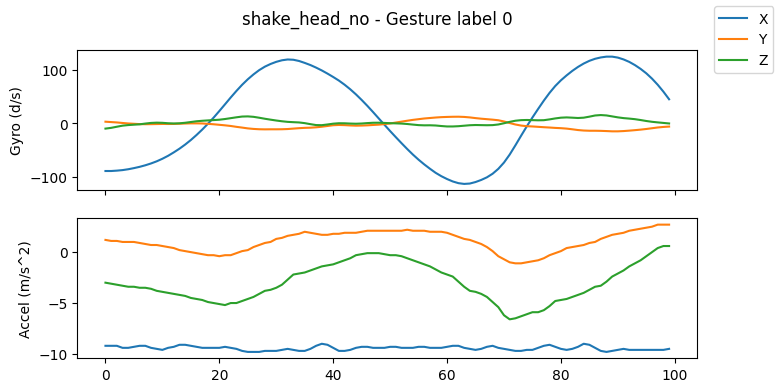

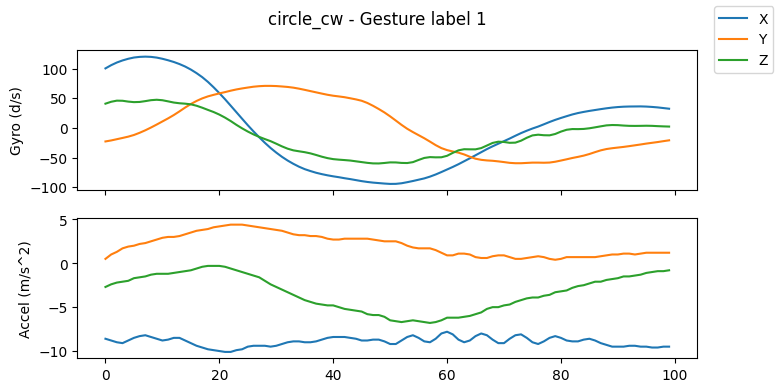

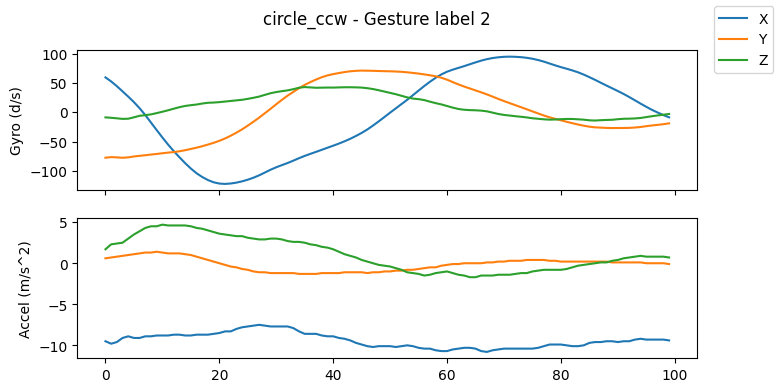

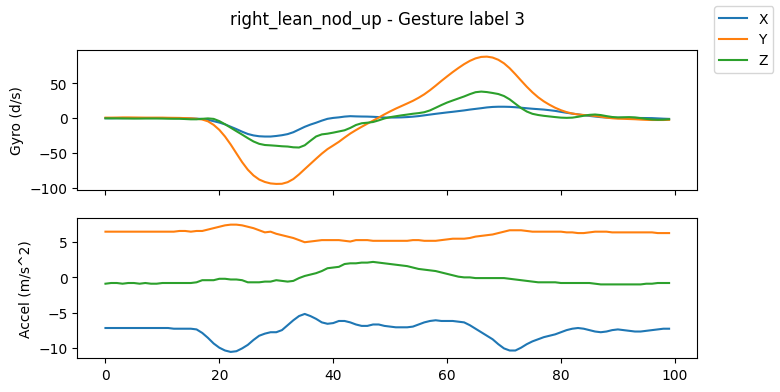

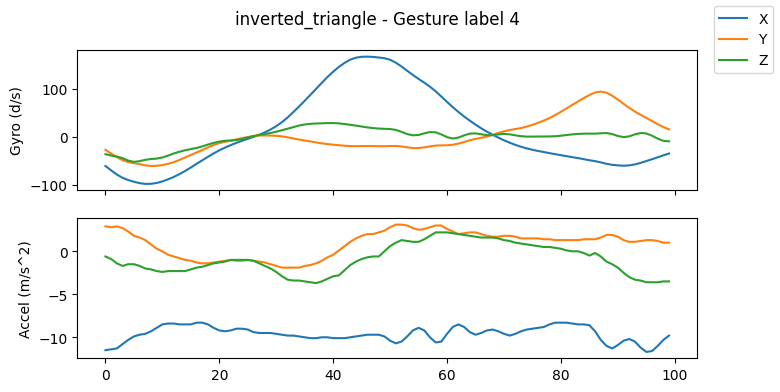

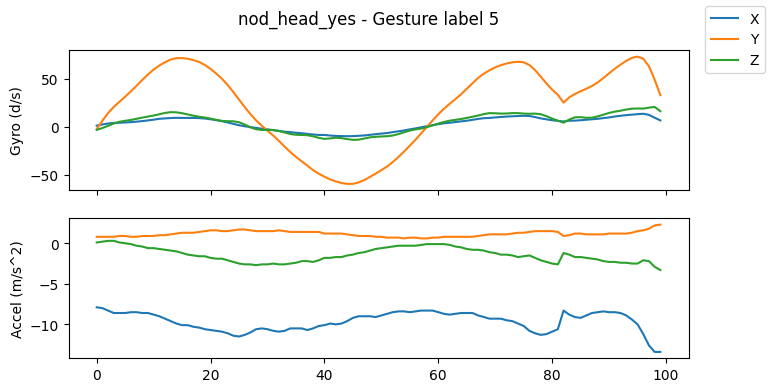

In [4]:
import random
import pandas as pd
import matplotlib.pyplot as plt

WIN = 100
out_arr = []

# Process each gesture in gest_arr
for gest, start, end in trim_gest_arr:
    gest_len = end - start
    gest_center = int((end + start) / 2)
    win = (int(gest_center - WIN / 2), int(gest_center + WIN / 2))
    # print(win)

    # If gesture window cannot be centered, skip it
    if win[0] < 0 or win[1] >= len(gest.index):
        print("Aw dang! Out of bounds")
        continue

    # Append valid gestures to out_arr
    extracted_gesture = gest.iloc[win[0]:win[1]].reset_index(drop=True)
    if len(extracted_gesture) == WIN:  # Ensure it's 100 samples
        out_arr.append(extracted_gesture)



print("Number of gestures:", len(out_arr))
print("Shape of sample gesture arrays:")


# Concatenate the data into a single DataFrame
df = pd.concat(out_arr)

# Get unique gesture labels
unique_labels = df['gesture_name'].unique()

# Generate graphs for each gesture label
for label in unique_labels:
    # Filter data for the current gesture label
    gesture_data = df[df['gesture_name'] == label]

    selected_sample = gesture_data.iloc[:100] # Select the first 100 samples for plotting
    gesture_id = gesture_data.iloc[0]['gesture_id']

    # Create the plot
    fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True)
    fig.set_size_inches(8, 4)

    # Plot gyroscope data from selected_sample
    ax[0].plot(selected_sample.index, selected_sample[["gyro_x", "gyro_y", "gyro_z"]], label=("X", "Y", "Z"))
    ax[0].set_ylabel("Gyro (d/s)")

    # Plot accelerometer data from selected_sample
    ax[1].plot(selected_sample.index, selected_sample[["acc_x", "acc_y", "acc_z"]])
    ax[1].set_ylabel("Accel (m/s^2)")

    # Add a legend and title
    fig.legend()
    fig.suptitle(f"{label} - Gesture label {gesture_id}")

    print(selected_sample.shape)

# Print the unique gesture labels
print("Gesture class labels:", unique_labels)


    # fig.savefig(f"images/{sample_num}_{gest['GestureLabel'][0]}")
    # plt.close(fig)


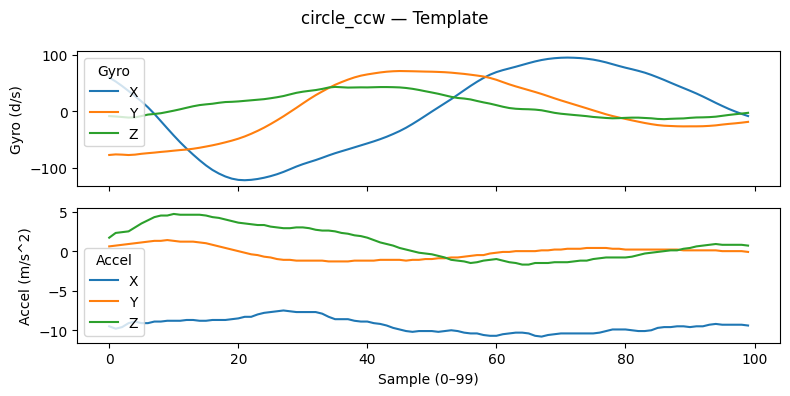

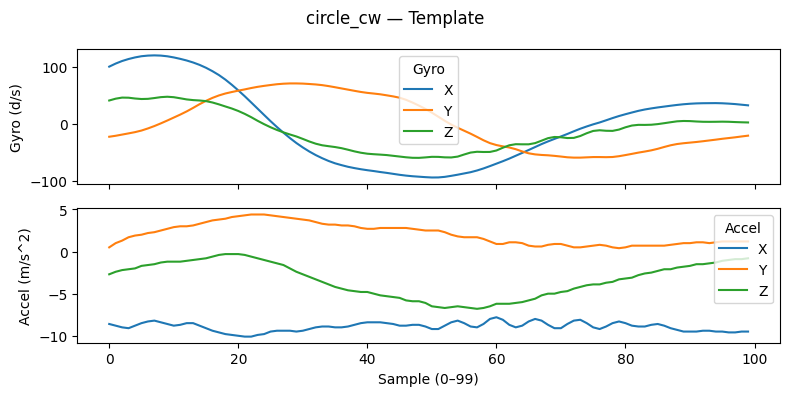

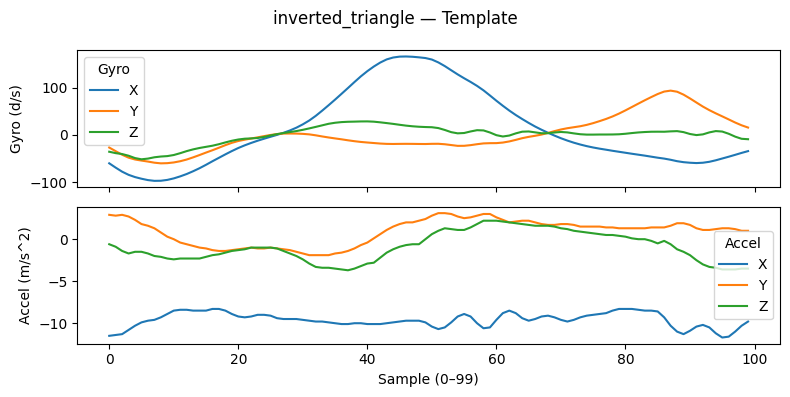

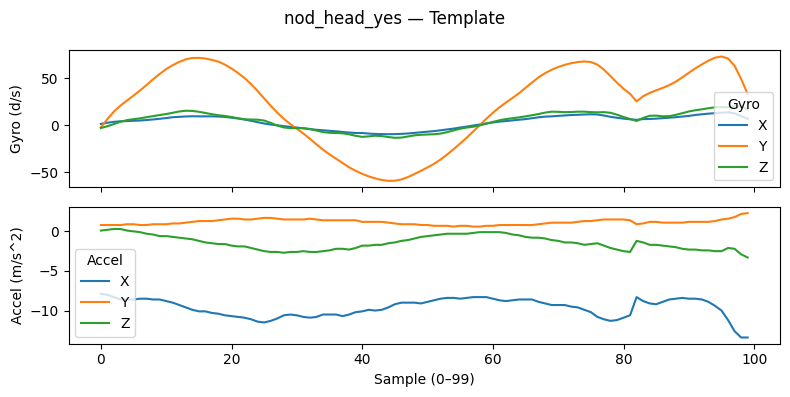

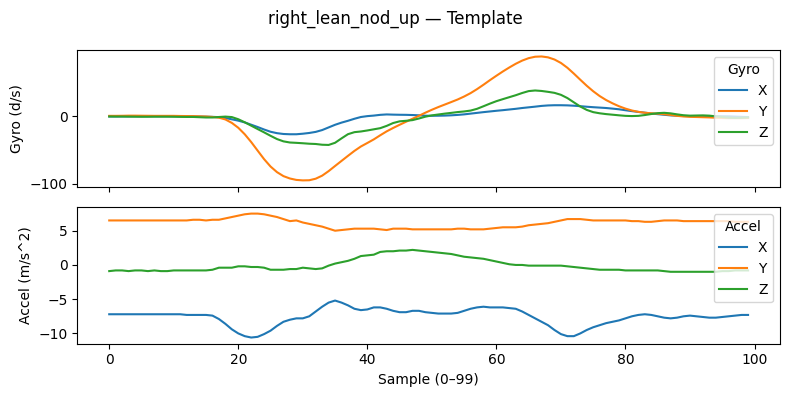

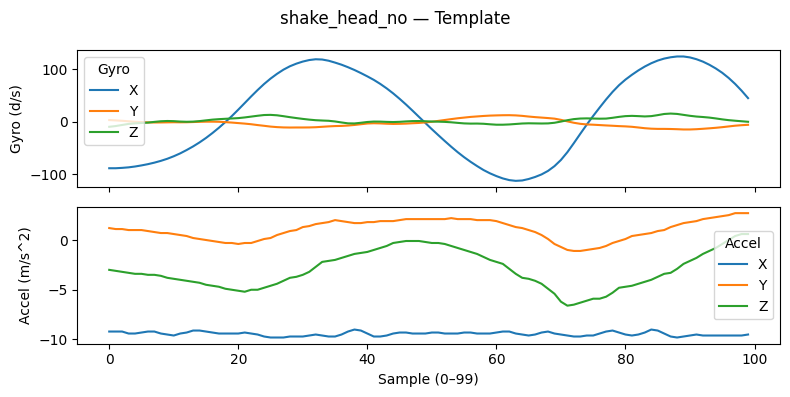

In [5]:
# Creating templates for each gesture class

imu_cols = ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]

# 2) Concatenate all windows, tagging each row with its time index 0..99
stack = []
for df in out_arr:
    d = df.copy()
    # ensure exactly 100 rows and clean index
    d = d.reset_index(drop=True)
    if len(d) != 100:
        continue
    d["t"] = np.arange(100)  # time index within window
    stack.append(d[["gesture_name", "t", *imu_cols]])

all_rows = pd.concat(stack, ignore_index=True)

# 3) For each (gesture_name, t), average the IMU channels
#    This yields a MultiIndex DataFrame indexed by (gesture_name, t)
templates = (
    all_rows
    .groupby(["gesture_name", "t"], sort=True)[imu_cols]
    .mean()
    .round(3)
)

# Optional: same thing but as DataFrames with nice columns
templates_df = {
    g: grp.reset_index(level="t").sort_values("t")[imu_cols].reset_index(drop=True)
    for g, grp in templates.groupby(level="gesture_name")
}

# ---------- Plot each gesture template ----------
for gesture_name, tpl in templates_df.items():
    fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(8, 4))

    # Top: Gyroscope (X,Y,Z)
    ax[0].plot(np.arange(len(tpl)), tpl[["gyro_x", "gyro_y", "gyro_z"]], label=("X", "Y", "Z"))
    ax[0].set_ylabel("Gyro (d/s)")
    ax[0].legend(title="Gyro")

    # Bottom: Accelerometer (X,Y,Z)
    ax[1].plot(np.arange(len(tpl)), tpl[["acc_x", "acc_y", "acc_z"]], label=("X", "Y", "Z"))
    ax[1].set_ylabel("Accel (m/s^2)")
    ax[1].set_xlabel("Sample (0–99)")
    ax[1].legend(title="Accel")

    fig.suptitle(f"{gesture_name} — Template")
    fig.tight_layout()
    plt.show()

In [6]:
# Folder to save both CSVs and plots
save_dir = r"C:\Repositories\gesture_models\Cross Correlation Models\2_Sandra_custom"
os.makedirs(save_dir, exist_ok=True)

# --- Save CSVs ---
for gesture_name, df in templates_df.items():
    csv_path = os.path.join(save_dir, f"{gesture_name}_template.csv")
    df.to_csv(csv_path, index=False)
    print(f"Saved {csv_path}")

# --- Save plots ---
for gesture_name, tpl in templates_df.items():
    fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(8, 4))

    # Gyroscope
    ax[0].plot(np.arange(len(tpl)), tpl[["gyro_x", "gyro_y", "gyro_z"]])
    ax[0].set_ylabel("Gyro (d/s)")
    ax[0].legend(["X", "Y", "Z"], title="Gyro")

    # Accelerometer
    ax[1].plot(np.arange(len(tpl)), tpl[["acc_x", "acc_y", "acc_z"]])
    ax[1].set_ylabel("Accel (m/s^2)")
    ax[1].set_xlabel("Sample (0–99)")
    ax[1].legend(["X", "Y", "Z"], title="Accel")

    fig.suptitle(f"{gesture_name} — Template")
    fig.tight_layout()

    # Save instead of show
    plot_path = os.path.join(save_dir, f"{gesture_name}_template.png")
    fig.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.close(fig)   # close to free memory

    print(f"Saved {plot_path}")

Saved C:\Repositories\gesture_models\Cross Correlation Models\2_Sandra_custom\circle_ccw_template.csv
Saved C:\Repositories\gesture_models\Cross Correlation Models\2_Sandra_custom\circle_cw_template.csv
Saved C:\Repositories\gesture_models\Cross Correlation Models\2_Sandra_custom\inverted_triangle_template.csv
Saved C:\Repositories\gesture_models\Cross Correlation Models\2_Sandra_custom\nod_head_yes_template.csv
Saved C:\Repositories\gesture_models\Cross Correlation Models\2_Sandra_custom\right_lean_nod_up_template.csv
Saved C:\Repositories\gesture_models\Cross Correlation Models\2_Sandra_custom\shake_head_no_template.csv
Saved C:\Repositories\gesture_models\Cross Correlation Models\2_Sandra_custom\circle_ccw_template.png
Saved C:\Repositories\gesture_models\Cross Correlation Models\2_Sandra_custom\circle_cw_template.png
Saved C:\Repositories\gesture_models\Cross Correlation Models\2_Sandra_custom\inverted_triangle_template.png
Saved C:\Repositories\gesture_models\Cross Correlation Mod

In [3]:
import re

# ===== USER INPUT =====
folder_path = Path("C:\\Repositories\\gesture_models\\Cross Correlation Models\\2_Sandra_custom\\gesture_templates")  
TEMPLATE_SIZE = 100
CHANNELS = ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]

# ======================

def normalize(s):
    return re.sub(r"[^a-z0-9]+", "", str(s).strip().lower())

def format_float(v):
    if abs(v) < 1e-9:
        return "0"
    s = f"{v:.3f}"
    return s.rstrip("0").rstrip(".")

def convert_csv_to_matrix(csv_path):
    df = pd.read_csv(csv_path)

    # Normalize column names
    df.columns = [normalize(c) for c in df.columns]

    # Try to auto-detect channel columns
    norm_channels = [normalize(c) for c in CHANNELS]

    if all(ch in df.columns for ch in norm_channels):
        df = df[norm_channels]
    else:
        # Assume first 6 columns are ax, ay, az, gx, gy, gz
        df = df.iloc[:, :6]
        df.columns = norm_channels

    if len(df) != TEMPLATE_SIZE:
        raise ValueError(f"{csv_path.name}: expected {TEMPLATE_SIZE} rows, got {len(df)}")

    rows = df.values.tolist()

    # Convert to C initializer
    formatted_rows = []
    for r in rows:
        formatted_rows.append("{" + ",".join(format_float(float(v)) for v in r) + "}")
    
    return "{" + ",".join(formatted_rows) + "}"

# ===== PROCESS ALL CSV FILES =====

csv_files = sorted(folder_path.glob("*.csv"))

if len(csv_files) != 6:
    print(f"Warning: Expected 6 CSV files, found {len(csv_files)}")

gesture_macros = []
gesture_names = []

for csv_file in csv_files:
    gesture_name = csv_file.stem.upper()
    gesture_names.append(gesture_name)

    matrix_literal = convert_csv_to_matrix(csv_file)
    macro = f"#define {gesture_name}\t{matrix_literal}"
    gesture_macros.append(macro)

# ===== PRINT OUTPUT =====

print("\n\n===== COPY BELOW INTO templates.h =====\n")

for macro in gesture_macros:
    print(macro)
    print()

print("static const float templates[][100][6] = {")
for name in gesture_names:
    print(f"\t{name},")
print("};\n")

print("static const char * const template_names[] = {")
for name in gesture_names:
    print(f'\t"{name}",')
print("};")



===== COPY BELOW INTO templates.h =====

#define CIRCLE_CCW_TEMPLATE	{{-9.5,0.6,1.7,59.4,-77.6,-8.8},{-9.8,0.7,2.3,52.5,-76.6,-9.5},{-9.6,0.8,2.4,44.4,-77,-10.4},{-9.1,0.9,2.5,35.6,-77.7,-11.4},{-8.9,1,3,26.6,-77,-11.1},{-9.1,1.1,3.5,17.2,-75.5,-8.7},{-9.1,1.2,3.9,6.8,-74.4,-6.1},{-8.9,1.3,4.3,-4.9,-73.4,-5},{-8.9,1.3,4.5,-17.7,-72.2,-3.7},{-8.8,1.4,4.5,-30.5,-71.2,-1.5},{-8.8,1.3,4.7,-43.1,-70,0.8},{-8.8,1.2,4.6,-55.2,-68.9,3.3},{-8.7,1.2,4.6,-66.4,-68,6},{-8.7,1.2,4.6,-76.9,-66.6,8.6},{-8.8,1.1,4.6,-86.9,-64.8,10.7},{-8.8,1,4.5,-96.1,-62.7,12},{-8.7,0.8,4.3,-104.1,-60.5,13.1},{-8.7,0.6,4.2,-110.5,-58,14.8},{-8.7,0.4,4,-115.7,-55.2,16.1},{-8.6,0.2,3.8,-119.5,-52.2,16.5},{-8.5,0,3.6,-121.7,-48.8,17.2},{-8.3,-0.2,3.5,-122.3,-44.8,18.2},{-8.3,-0.4,3.4,-121.6,-40.1,19.2},{-8,-0.5,3.3,-120.1,-34.9,20.2},{-7.8,-0.7,3.3,-117.9,-29.2,21.2},{-7.7,-0.8,3.1,-115.1,-22.9,22.8},{-7.6,-1,3,-111.7,-16.2,24.6},{-7.5,-1.1,2.9,-107.6,-9.2,26.7},{-7.6,-1.1,2.9,-102.9,-1.7,29.6},{-7.7,-1.2,3,-98.1,5.8,